# Calculation in CV

## Convolution

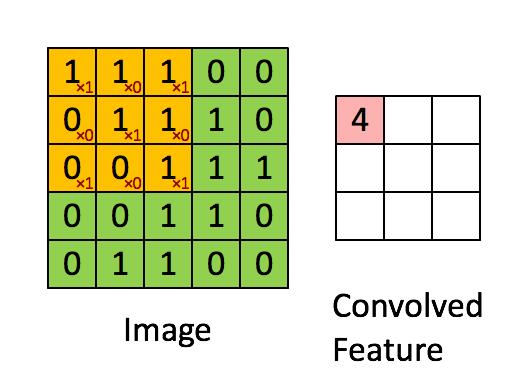

![conv](conv.gif)

- Padding: Fill zeros around input to adjust output size
- Stride: Sliding step size of convolution kernel; larger stride → smaller output
- Output dimension formula:
  $$
  out_{size}=\frac{H+2P-K}{S}+1
  $$

$H=input height, P=padding, K=kernel size, S=stride$


In [1]:
import numpy as np

# Manual 2D convolution implementation
def conv2d(input_mat, kernel, padding=0, stride=1):
    # Get input and kernel dimensions
    H, W = input_mat.shape
    kh, kw = kernel.shape

    # Zero-padding around input matrix
    if padding > 0:
        input_mat = np.pad(input_mat, pad_width=padding, mode='constant')

    # Calculate output feature map size
    out_h = (H + 2 * padding - kh) // stride + 1
    out_w = (W + 2 * padding - kw) // stride + 1
    output = np.zeros((out_h, out_w))

    # Slide kernel with specified stride and compute convolution
    for i in range(0, H + 2 * padding - kh + 1, stride):
        for j in range(0, W + 2 * padding - kw + 1, stride):
            window = input_mat[i:i+kh, j:j+kw]
            output[i//stride, j//stride] = np.sum(window * kernel)
    return output

In [2]:
# Test cases
# input matrix
img = np.array([[1, 2, 3],
                [4, 5, 6],
                [7, 8, 9]])
# Convolution kernel
kernel = np.array([[1, 0],
                   [0, 1]])

print("Original input matrix:")
print(img)

# Case1: padding=0, stride=1
print("\n--- padding=0, stride=1 ---")
print(conv2d(img, kernel, padding=0, stride=1))

# Case2: padding=1, stride=1
print("\n--- padding=1, stride=1 ---")
print(conv2d(img, kernel, padding=1, stride=1))

# Case3: padding=0, stride=2
print("\n--- padding=0, stride=2 ---")
print(conv2d(img, kernel, padding=0, stride=2))

Original input matrix:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

--- padding=0, stride=1 ---
[[ 6.  8.]
 [12. 14.]]

--- padding=1, stride=1 ---
[[ 1.  2.  3.  0.]
 [ 4.  6.  8.  3.]
 [ 7. 12. 14.  6.]
 [ 0.  7.  8.  9.]]

--- padding=0, stride=2 ---
[[6.]]


## Parameters in CNN

**AlexNet** for example

Input: 3×224×224 RGB Image

    ↓ Conv1(k=11,s=4,p=2) | Params:34,944 → 96×55×55
    
    ↓ ReLU → MaxPool(k=3,s=2)               → 96×27×27
    
    ↓ Conv2(k=5,s=1,p=2) | Params:614,656 →256×27×27
    
    ↓ ReLU → MaxPool(k=3,s=2)               →256×13×13
    
    ↓ Conv3(k=3,s=1,p=1) | Params:885,120 →384×13×13
    
    ↓ ReLU
    
    ↓ Conv4(k=3,s=1,p=1) | Params:1,327,488→384×13×13
    
    ↓ ReLU
    
    ↓ Conv5(k=3,s=1,p=1) | Params:884,992 →256×13×13
    
    ↓ ReLU → MaxPool(k=3,s=2)               →256×6×6
    
    ↓ Flatten → 9216-dim vector
    
    ↓ FC1                  | Params:37,752,832 →4096
    
    ↓ Dropout+ReLU
    
    ↓ FC2                  | Params:16,781,312 →4096
    
    ↓ Dropout+ReLU
    
    ↓ FC3                  | Params:4,097,000  →1000(ImageNet class)

In [9]:
import torch
import torch.nn as nn

# Minimal AlexNet (ImageNet-1K, original structure)
class AlexNet(nn.Module):
    def __init__(self, num_classes=1000):
        super(AlexNet, self).__init__()
        # Convolutional layers
        self.features = nn.Sequential(
            # Conv1
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Conv2
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            # Conv3
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            # Conv4
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            # Conv5
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        # Fully connected layers
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# ==========================
# Core Formulas
# ==========================
def output_size(H, K, P, S):
    return (H + 2*P - K) // S + 1

def conv_params(in_c, out_c, K):
    return (K * K * in_c + 1) * out_c  # +1 for bias

def linear_params(in_f, out_f):
    return (in_f + 1) * out_f


In [10]:
model = AlexNet()
x = torch.randn(1, 3, 224, 224)

# Print Layer-wise Details
print("="*90)
print("                 AlexNet Layer-wise Calculation (224x224 Input)")
print("="*90)

# Convolution Layers
layers = [
    ("Conv1", 3, 96, 11, 4, 2),
    ("Conv2", 96, 256, 5, 1, 2),
    ("Conv3", 256, 384, 3, 1, 1),
    ("Conv4", 384, 384, 3, 1, 1),
    ("Conv5", 384, 256, 3, 1, 1),
]

H = 224
for name, in_c, out_c, K, S, P in layers:
    OH = output_size(H, K, P, S)
    params = conv_params(in_c, out_c, K)
    print(f"{name:5s} | In: {H}x{H}x{in_c:3d} | Out: {OH:2d}x{OH:2d}x{out_c:3d} | Params: {params:8,} = ({K}²×{in_c}+1)×{out_c}")
    H = OH
    if name in ["Conv1", "Conv2", "Conv5"]:
        H = output_size(H, 3, 0, 2)

# Flatten
print("-"*90)
print(f"Flatten  | In: {H}x{H}x256 | Out: {H*H*256:,} features")
print("-"*90)

# Fully Connected Layers
fc_layers = [
    ("FC1", 256*6*6, 4096),
    ("FC2", 4096, 4096),
    ("FC3", 4096, 1000),
]

for name, in_f, out_f in fc_layers:
    params = linear_params(in_f, out_f)
    print(f"{name:5s} | In: {in_f:8,} | Out: {out_f:4,} | Params: {params:9,} = ({in_f}+1)×{out_f}")

# Total Parameters
total_params = sum(p.numel() for p in model.parameters())
print("="*90)
print(f"Total Parameters: {total_params:,}")
print("="*90)

                 AlexNet Layer-wise Calculation (224x224 Input)
Conv1 | In: 224x224x  3 | Out: 55x55x 96 | Params:   34,944 = (11²×3+1)×96
Conv2 | In: 27x27x 96 | Out: 27x27x256 | Params:  614,656 = (5²×96+1)×256
Conv3 | In: 13x13x256 | Out: 13x13x384 | Params:  885,120 = (3²×256+1)×384
Conv4 | In: 13x13x384 | Out: 13x13x384 | Params: 1,327,488 = (3²×384+1)×384
Conv5 | In: 13x13x384 | Out: 13x13x256 | Params:  884,992 = (3²×384+1)×256
------------------------------------------------------------------------------------------
Flatten  | In: 6x6x256 | Out: 9,216 features
------------------------------------------------------------------------------------------
FC1   | In:    9,216 | Out: 4,096 | Params: 37,752,832 = (9216+1)×4096
FC2   | In:    4,096 | Out: 4,096 | Params: 16,781,312 = (4096+1)×4096
FC3   | In:    4,096 | Out: 1,000 | Params: 4,097,000 = (4096+1)×1000
Total Parameters: 62,378,344
